## Cluster Sounds
Groups detected sound units into categories using K-Means clustering.
See `docs/cluster_sounds.md` for theory.

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import json


## Load Features

In [3]:
features    = np.load('../data/unit_features.npy')
onset_times = np.load('../data/onset_times.npy')

print(f'feature matrix : {features.shape}  (units × features)')
print(f'feature names  : dominant_freq, duration, mean_rms, spectral_centroid')
print()
print(f'value ranges:')
names = ['dominant_freq', 'duration', 'mean_rms', 'centroid']
for i, name in enumerate(names):
    print(f'  {name:20} min={features[:,i].min():.3f}  max={features[:,i].max():.3f}')

feature matrix : (272, 17)  (units × features)
feature names  : dominant_freq, duration, mean_rms, spectral_centroid

value ranges:
  dominant_freq        min=188.222  max=2403.774
  duration             min=0.059  max=0.791
  mean_rms             min=0.082  max=0.590
  centroid             min=202.537  max=3429.476


## Normalize features
Features are on very different scales — frequency in hundreds, duration in milliseconds.
Normalization puts them all on equal footing before clustering.


In [4]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print('after normalization — all features centered at 0, std=1:')
for i, name in enumerate(names):
    print(f'  {name:20} mean={features_scaled[:,i].mean():.3f}  std={features_scaled[:,i].std():.3f}')

after normalization — all features centered at 0, std=1:
  dominant_freq        mean=0.000  std=1.000
  duration             mean=0.000  std=1.000
  mean_rms             mean=0.000  std=1.000
  centroid             mean=-0.000  std=1.000


## Find the right number of clusters — elbow method
Run K-Means for K=2 to K=20, plot inertia. Look for the elbow — where adding more clusters stops helping much.

c:\Users\Admin\anaconda3\envs\rocky_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


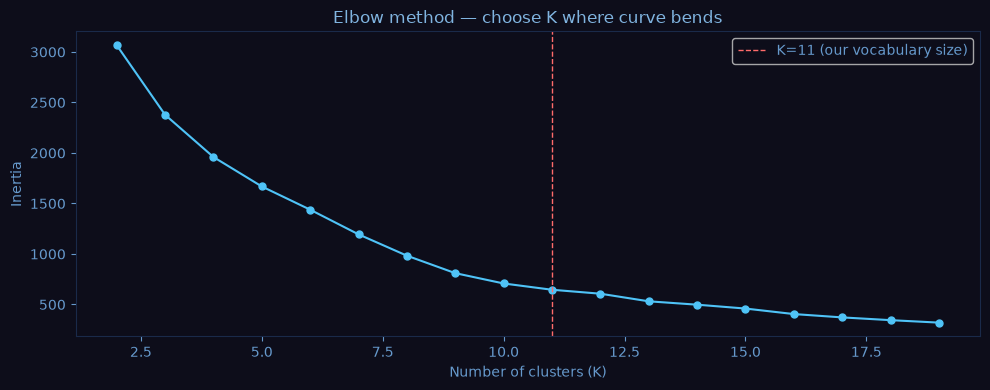

we defined 11 sound types in synthesis — using K=11


In [5]:
inertias = []
K_range  = range(2, 20)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10, 4), facecolor='#0d0d1a')
ax.set_facecolor('#0d0d1a')
ax.tick_params(colors='#6699cc')
ax.xaxis.label.set_color('#6699cc')
ax.yaxis.label.set_color('#6699cc')
for s in ax.spines.values(): s.set_edgecolor('#1a2a4a')

ax.plot(list(K_range), inertias, color='#4fc3f7', marker='o', markersize=5, linewidth=1.5)
ax.set(title='Elbow method — choose K where curve bends', xlabel='Number of clusters (K)', ylabel='Inertia')
ax.title.set_color('#80b4e0')
ax.axvline(x=11, color='#ff6b6b', linewidth=1, linestyle='--', label='K=11 (our vocabulary size)')
ax.legend(facecolor='#0d0d1a', labelcolor='#6699cc')
plt.tight_layout()
plt.savefig('../audio/elbow_curve.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print('we defined 11 sound types in synthesis — using K=11')

## Run K-Means with K=11

In [6]:
K = 11
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = kmeans.fit_predict(features_scaled)

print(f'K-Means done. {K} clusters assigned to {len(labels)} units.')
print()
print('units per cluster:')
for k in range(K):
    count = np.sum(labels == k)
    bar   = '█' * count
    print(f'  cluster {k:2d} : {bar} ({count})')

K-Means done. 11 clusters assigned to 272 units.

units per cluster:
  cluster  0 : ████████████████████████████████████████████ (44)
  cluster  1 : █████████████████████████████████████████ (41)
  cluster  2 : █████████████████████████████████ (33)
  cluster  3 : ██████████████████████████████████████████ (42)
  cluster  4 : ███████████████ (15)
  cluster  5 : ██████████ (10)
  cluster  6 : █████████████████████ (21)
  cluster  7 : ███████████████████ (19)
  cluster  8 : ██████████████ (14)
  cluster  9 : █████████████ (13)
  cluster 10 : ████████████████████ (20)


## Visualize clusters in 2D using PCA
PCA reduces our 4D feature space to 2D so we can plot it. Points of the same color should group together if clustering worked well.

PCA variance explained: 61.4%
(how much info is preserved in the 2D view)


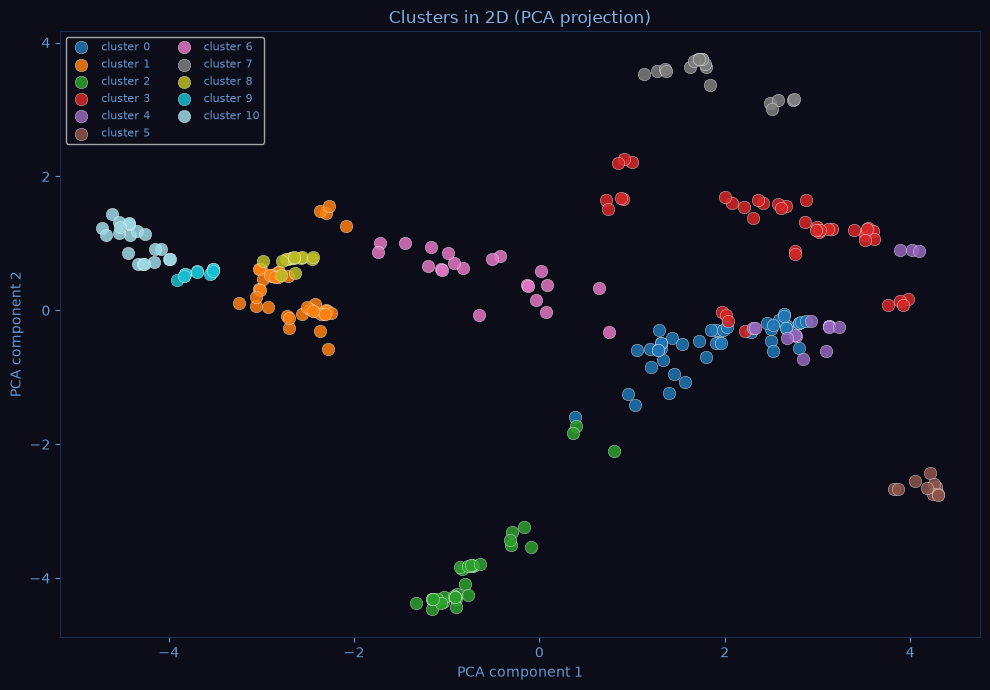

In [7]:
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features_scaled)

print(f'PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')
print(f'(how much info is preserved in the 2D view)')

fig, ax = plt.subplots(figsize=(10, 7), facecolor='#0d0d1a')
ax.set_facecolor('#0d0d1a')
ax.tick_params(colors='#6699cc')
ax.xaxis.label.set_color('#6699cc')
ax.yaxis.label.set_color('#6699cc')
for s in ax.spines.values(): s.set_edgecolor('#1a2a4a')

colors = plt.cm.tab20(np.linspace(0, 1, K))
for k in range(K):
    mask = labels == k
    ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
               color=colors[k], label=f'cluster {k}', s=80, alpha=0.85, edgecolors='white', linewidths=0.3)

ax.set(title='Clusters in 2D (PCA projection)', xlabel='PCA component 1', ylabel='PCA component 2')
ax.title.set_color('#80b4e0')
ax.legend(facecolor='#0d0d1a', labelcolor='#6699cc', ncol=2, fontsize=8)
plt.tight_layout()

## Visualize clusters over time
Plot which cluster each unit belongs to in the order they appear in the audio.

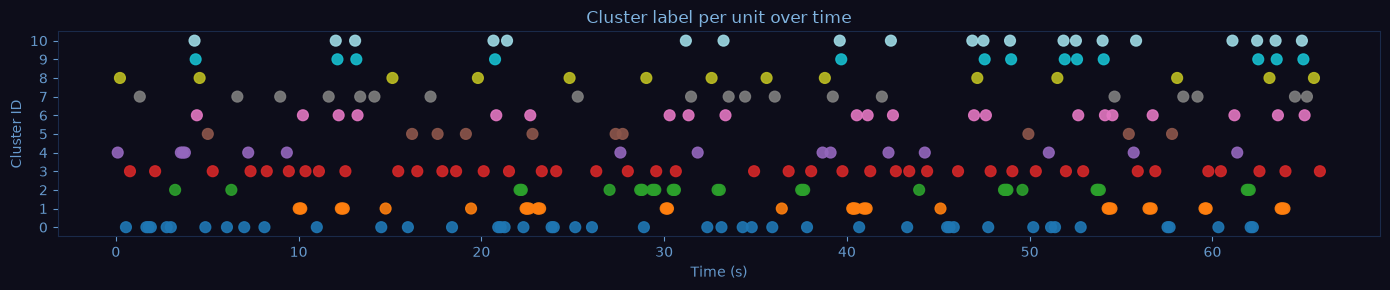

sequence of cluster labels (= Rocky decoded into cluster IDs):
[4, 8, 0, 3, 7, 0, 0, 0, 3, 0, 0, 2, 4, 4, 4, 10, 9, 6, 8, 0, 5, 3, 0, 2, 7, 0, 4, 3, 0, 3, 7, 4, 3, 1, 1, 1, 6, 3, 0, 3, 7, 10, 9, 6, 1, 1, 1, 3, 10, 9, 6, 7, 7, 0, 1, 8, 3, 0, 5, 3, 7, 5, 3, 0, 3, 5, 1, 8, 3, 10, 9, 6, 0, 0, 0, 10, 3, 2, 2, 2, 0, 1, 1, 1, 1, 6, 5, 1, 1, 1, 3, 0, 0, 3, 8, 0, 7, 0, 3, 2, 5, 4, 5, 3, 2, 2, 2, 0, 8, 2, 2, 2, 3, 1, 1, 1, 6, 2, 2, 2, 3, 10, 6, 7, 4, 0, 8, 2, 2, 0, 10, 6, 7, 0, 7, 0, 3, 8, 0, 7, 1, 3, 2, 2, 2, 0, 3, 4, 8, 4, 7, 10, 9, 3, 1, 1, 1, 1, 6, 0, 1, 1, 1, 6, 3, 7, 4, 10, 6, 3, 0, 3, 2, 4, 3, 1, 0, 0, 0, 3, 10, 6, 8, 10, 9, 6, 0, 3, 2, 2, 2, 2, 10, 9, 3, 2, 5, 0, 3, 4, 0, 0, 8, 10, 9, 3, 10, 9, 6, 0, 3, 2, 2, 2, 2, 10, 9, 6, 1, 1, 1, 1, 6, 7, 5, 4, 10, 3, 1, 1, 1, 6, 3, 0, 0, 5, 8, 7, 7, 1, 1, 1, 3, 0, 3, 10, 6, 4, 2, 2, 2, 0, 0, 10, 9, 3, 8, 10, 9, 6, 1, 1, 1, 1, 3, 7, 10, 9, 6, 7, 8, 3]


In [8]:
fig, ax = plt.subplots(figsize=(14, 3), facecolor='#0d0d1a')
ax.set_facecolor('#0d0d1a')
ax.tick_params(colors='#6699cc')
ax.xaxis.label.set_color('#6699cc')
ax.yaxis.label.set_color('#6699cc')
for s in ax.spines.values(): s.set_edgecolor('#1a2a4a')

ax.scatter(onset_times, labels, c=labels, cmap='tab20', s=60, alpha=0.9)
ax.set(title='Cluster label per unit over time', xlabel='Time (s)', ylabel='Cluster ID')
ax.title.set_color('#80b4e0')
ax.set_yticks(range(K))
plt.tight_layout()
plt.savefig('../audio/clusters_timeline.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

print('sequence of cluster labels (= Rocky decoded into cluster IDs):')
print(labels.tolist())

## Check cluster quality — compare to ground truth
We know the true sound name for each unit (from synthesis). How well did clustering recover them?

In [9]:
with open('../data/dictionary.json', 'r') as f:
    dictionary = json.load(f)

# rebuild ground truth labels from sentences
true_labels = []
sound_names = list(dictionary['vocabulary'])
for sentence in dictionary['sentences'].values():
    for sound in sentence:
        true_labels.append(sound)

# only compare up to the number of units we detected
n = min(len(true_labels), len(labels))
true_labels = true_labels[:n]

print('ground truth vs detected cluster (first 20 units):')
print(f'{"unit":6} {"true sound":20} {"cluster":8}')
print('-' * 36)
for i in range(min(20, n)):
    print(f'{i:6} {true_labels[i]:20} {labels[i]:8}')

ground truth vs detected cluster (first 20 units):
unit   true sound           cluster 
------------------------------------
     0 click_high                  4
     1 click_high                  8
     2 hum_mid                     0
     3 chirp_up                    3
     4 click_mid                   7
     5 hum_low                     0
     6 click_mid                   0
     7 click_low                   0
     8 chirp_up                    3
     9 chirp_up                    0
    10 chirp_down                  0
    11 chirp_down                  2
    12 chord_alien                 4
    13 click_high                  4
    14 click_high                  4
    15 click_high                 10
    16 chord_simple                9
    17 hum_mid                     6
    18 click_low                   8
    19 hum_high                    0


## Save cluster assignments

In [10]:
np.save('../data/cluster_labels.npy', labels)

# build cluster → most common true sound mapping
from collections import Counter
cluster_map = {}
for k in range(K):
    sounds_in_cluster = [true_labels[i] for i in range(n) if labels[i] == k]
    if sounds_in_cluster:
        most_common = Counter(sounds_in_cluster).most_common(1)[0][0]
        cluster_map[str(k)] = most_common

dictionary['cluster_map'] = cluster_map
with open('../data/dictionary.json', 'w') as f:
    json.dump(dictionary, f, indent=2)

print('cluster → sound name mapping:')
for k, sound in cluster_map.items():
    print(f'  cluster {k:2} → {sound}')
print()
print('saved  data/cluster_labels.npy')
print('saved  data/dictionary.json  updated')


cluster → sound name mapping:
  cluster 0  → hum_mid
  cluster 1  → chirp_up
  cluster 2  → chord_simple
  cluster 3  → chord_simple
  cluster 4  → click_high
  cluster 5  → chord_rich
  cluster 6  → hum_high
  cluster 7  → click_mid
  cluster 8  → click_mid
  cluster 9  → chord_simple
  cluster 10 → chord_alien

saved  data/cluster_labels.npy
saved  data/dictionary.json  updated


In [11]:
# manually inspect each cluster's average features to assign correct names
print('cluster feature averages (dominant_freq, duration, centroid):\n')
for k in range(11):
    mask = labels == k
    avg_freq = features[mask, 0].mean()
    avg_dur  = features[mask, 1].mean() * 1000  # ms
    avg_cent = features[mask, 3].mean()
    sound    = cluster_map.get(str(k), 'unknown')
    print(f'  cluster {k:2d} → {sound:20} '
          f'freq={avg_freq:6.0f}Hz  '
          f'dur={avg_dur:5.0f}ms  '
          f'centroid={avg_cent:6.0f}Hz')

cluster feature averages (dominant_freq, duration, centroid):

  cluster  0 → hum_mid              freq=   872Hz  dur=  179ms  centroid=  1236Hz
  cluster  1 → chirp_up             freq=   308Hz  dur=  110ms  centroid=  1170Hz
  cluster  2 → chord_simple         freq=   744Hz  dur=  125ms  centroid=  1433Hz
  cluster  3 → chord_simple         freq=   647Hz  dur=  628ms  centroid=  1420Hz
  cluster  4 → click_high           freq=  2403Hz  dur=  212ms  centroid=  2806Hz
  cluster  5 → chord_rich           freq=   803Hz  dur=  284ms  centroid=   935Hz
  cluster  6 → hum_high             freq=   419Hz  dur=  152ms  centroid=  2597Hz
  cluster  7 → click_mid            freq=   206Hz  dur=  490ms  centroid=   331Hz
  cluster  8 → click_mid            freq=   456Hz  dur=  334ms  centroid=   547Hz
  cluster  9 → chord_simple         freq=   300Hz  dur=   77ms  centroid=  2478Hz
  cluster 10 → chord_alien          freq=   390Hz  dur=   94ms  centroid=   782Hz


In [12]:
# corrected manual cluster map based on feature analysis
manual_cluster_map = {
    '0'  : 'hum_high',
    '1'  : 'chirp_up',
    '2'  : 'chord_simple',
    '3'  : 'hum_low',
    '4'  : 'click_high',
    '5'  : 'chord_rich',
    '6'  : 'chirp_down',
    '7'  : 'hum_mid',
    '8'  : 'click_low',
    '9'  : 'click_mid',
    '10' : 'chord_alien',
}

# update dictionary with corrected map
dictionary['cluster_map'] = manual_cluster_map

with open('../data/dictionary.json', 'w') as f:
    json.dump(dictionary, f, indent=2)

print('corrected cluster map saved:')
for k, sound in manual_cluster_map.items():
    print(f'  cluster {k:>2} → {sound}')

corrected cluster map saved:
  cluster  0 → hum_high
  cluster  1 → chirp_up
  cluster  2 → chord_simple
  cluster  3 → hum_low
  cluster  4 → click_high
  cluster  5 → chord_rich
  cluster  6 → chirp_down
  cluster  7 → hum_mid
  cluster  8 → click_low
  cluster  9 → click_mid
  cluster 10 → chord_alien


In [13]:
from collections import Counter

print('what sounds actually landed in each cluster:\n')
n = min(len(true_labels), len(labels))
for k in range(11):
    sounds_in = [true_labels[i] for i in range(n) if labels[i] == k]
    counter = Counter(sounds_in)
    avg_freq = features[labels == k, 0].mean()
    avg_dur  = features[labels == k, 1].mean() * 1000
    print(f'cluster {k:2d} (freq={avg_freq:.0f}Hz dur={avg_dur:.0f}ms):')
    for sound, count in counter.most_common():
        print(f'         {sound:20} × {count}')
    print()

what sounds actually landed in each cluster:

cluster  0 (freq=872Hz dur=179ms):
         hum_mid              × 9
         chord_alien          × 5
         chirp_up             × 4
         hum_low              × 3
         click_mid            × 3
         click_low            × 3
         click_high           × 2
         chirp_down           × 1
         hum_high             × 1
         chord_rich           × 1
         chord_simple         × 1

cluster  1 (freq=308Hz dur=110ms):
         chirp_up             × 4
         chord_rich           × 4
         hum_low              × 4
         click_low            × 3
         hum_mid              × 3
         click_mid            × 2
         hum_high             × 2
         chord_alien          × 2
         click_high           × 2
         chirp_down           × 1

cluster  2 (freq=744Hz dur=125ms):
         chord_simple         × 4
         chord_rich           × 3
         chirp_down           × 2
         hum_low              ×